This file will be converted to Jupyter notebook
Run this in a Jupyter cell or convert with: jupytext --to notebook EEG_Cognitive_Load_Best_Model.py

In [1]:
"""
# 🧠 EEG Cognitive Load Classification - Random Forest Model Analysis
## Complete Notebook with Visualizations and Results
"""

'\n# 🧠 EEG Cognitive Load Classification - Random Forest Model Analysis\n## Complete Notebook with Visualizations and Results\n'

In [2]:
# ## 1. Setup & Imports
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_auc_score, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import json
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Add src to path
sys.path.insert(0, '../src')
from data_loader import load_and_epoch_data
from preprocessing import subject_aware_train_test_split

In [5]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
print("✓ All imports successful!")

✓ All imports successful!


## 2. Feature Extraction Function

In [7]:
def extract_best_features(X, sfreq):
    """
    Extract the 5 best features for cognitive load classification:
    1. Frontal Theta-Beta Ratio
    2. Frontal Theta Power
    3. Central Beta Power
    4. Frontal Beta2 Power (15-22 Hz)
    5. Spectral Entropy
    """
    n_epochs, n_channels, n_samples = X.shape
    features = np.zeros((n_epochs, 5))
    
    theta_band = (4, 8)
    beta2_band = (15, 22)
    beta_band = (12, 30)
    
    frontal_left = [0, 2, 4]
    frontal_right = [1, 3, 5]
    central = [8, 9, 17]
    
    for epoch_idx in range(n_epochs):
        frontal_data = X[epoch_idx, frontal_left + frontal_right].mean(axis=0)
        central_data = X[epoch_idx, central].mean(axis=0)
        
        freqs, frontal_psd = signal.welch(frontal_data, sfreq, nperseg=min(256, n_samples))
        _, central_psd = signal.welch(central_data, sfreq, nperseg=min(256, n_samples))
        
        theta_mask = (freqs >= theta_band[0]) & (freqs < theta_band[1])
        beta2_mask = (freqs >= beta2_band[0]) & (freqs < beta2_band[1])
        beta_mask = (freqs >= beta_band[0]) & (freqs < beta_band[1])
        
        frontal_theta = frontal_psd[theta_mask].mean()
        frontal_beta = frontal_psd[beta_mask].mean()
        frontal_beta2 = frontal_psd[beta2_mask].mean()
        central_beta = central_psd[beta_mask].mean()
        
        theta_beta_ratio = (frontal_theta + 1e-8) / (frontal_beta + 1e-8)
        
        combined_psd = np.concatenate([frontal_psd, central_psd])
        psd_norm = combined_psd / (combined_psd.sum() + 1e-10)
        spectral_ent = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))
        
        features[epoch_idx] = [
            theta_beta_ratio,
            frontal_theta,
            central_beta,
            frontal_beta2,
            spectral_ent
        ]
    
    return features

In [8]:
print("✓ Feature extraction function defined!")

✓ Feature extraction function defined!


## 3. Load and Prepare Data

In [10]:
print("\n📊 Loading EEG Data...")
X, labels = load_and_epoch_data(data_dir='../data/raw')
print(f"✓ Loaded {X.shape[0]:,} epochs from {len(np.unique(labels['subject_id']))} subjects")
print(f"  Shape: {X.shape} (epochs, channels, samples)")
print(f"  Data range: [{X.min():.2e}, {X.max():.2e}]")


📊 Loading EEG Data...
✓ Loaded 8,604 epochs from 36 subjects
  Shape: (8604, 21, 1000) (epochs, channels, samples)
  Data range: [-3.27e+03, 4.47e+03]


## 4. Extract Features

In [11]:
print("\n🧬 Extracting Features...")
X_features = extract_best_features(X, sfreq=128)
print(f"✓ Features extracted: {X_features.shape}")


🧬 Extracting Features...
✓ Features extracted: (8604, 5)


In [12]:
feature_names = ['Theta-Beta Ratio', 'Frontal Theta', 'Central Beta', 'Frontal Beta2', 'Entropy']
feature_df = pd.DataFrame(X_features, columns=feature_names)

In [13]:
print("\n📈 Feature Statistics:")
print(feature_df.describe())


📈 Feature Statistics:
       Theta-Beta Ratio  Frontal Theta  Central Beta  Frontal Beta2  \
count       8604.000000    8604.000000  8.604000e+03   8.604000e+03   
mean        1923.450767       1.384727  1.955062e-03   9.585502e-05   
std         2369.796536       0.994864  2.844383e-03   2.331500e-04   
min            1.439789       0.000002  1.690497e-07   2.113446e-08   
25%          532.410051       0.763843  6.874799e-04   1.917263e-05   
50%          982.892909       1.126018  1.514885e-03   5.092015e-05   
75%         2396.932844       1.688803  2.368983e-03   1.036909e-04   
max        28175.225902      15.814762  9.986774e-02   8.801323e-03   

           Entropy  
count  8604.000000  
mean      4.164552  
std       0.323108  
min       2.099850  
25%       3.990808  
50%       4.198071  
75%       4.382323  
max       5.350744  


## 5. Visualize Feature Distributions

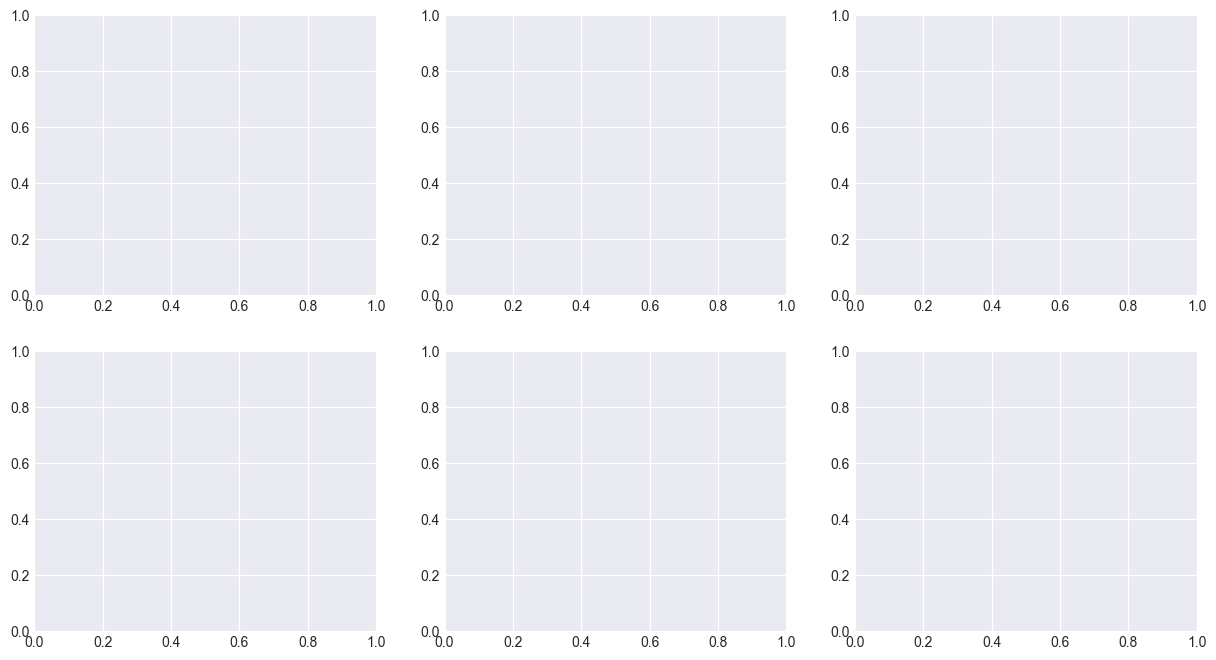

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

In [15]:
for idx, col in enumerate(feature_names):
    axes[idx].hist(feature_df[col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

In [16]:
axes[5].axis('off')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [17]:
print("✓ Feature distributions plotted")

✓ Feature distributions plotted


## 6. Train-Test Split

In [19]:
print("\n✂️ Splitting Data (Subject-Aware)...")
X_train, X_test, y_train, y_test = subject_aware_train_test_split(
    X, X_features, labels, test_size=0.2, random_state=42
)


✂️ Splitting Data (Subject-Aware)...


In [20]:
y_train_labels = y_train['session_type'] - 1
y_test_labels = y_test['session_type'] - 1

In [21]:
n_train_subjects = len(np.unique(y_train['subject_id']))
n_test_subjects = len(np.unique(y_test['subject_id']))

In [22]:
print(f"✓ Train set: {X_train.shape[0]:,} epochs from {n_train_subjects} subjects")
print(f"✓ Test set: {X_test.shape[0]:,} epochs from {n_test_subjects} subjects")
print(f"  Class distribution (train): Normal={sum(y_train_labels==0):,} | Mental Math={sum(y_train_labels==1):,}")
print(f"  Class distribution (test):  Normal={sum(y_test_labels==0):,} | Mental Math={sum(y_test_labels==1):,}")

✓ Train set: 6,770 epochs from 28 subjects
✓ Test set: 1,834 epochs from 8 subjects
  Class distribution (train): Normal=5,062 | Mental Math=1,708
  Class distribution (test):  Normal=1,346 | Mental Math=488


## 7. Scale Features

In [23]:
print("\n📏 Scaling Features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Features standardized (mean=0, std=1)")


📏 Scaling Features...
✓ Features standardized (mean=0, std=1)


## 8. Train Random Forest Model

In [24]:
print("\n🌲 Training Random Forest Model...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)


🌲 Training Random Forest Model...


In [25]:
rf_model.fit(X_train_scaled, y_train_labels)
print("✓ Model trained: 100 trees, max_depth=5")

✓ Model trained: 100 trees, max_depth=5


## 9. Make Predictions

In [26]:
print("\n🔮 Making Predictions...")
y_train_pred = rf_model.predict(X_train_scaled)
y_test_pred = rf_model.predict(X_test_scaled)
y_test_proba = rf_model.predict_proba(X_test_scaled)[:, 1]


🔮 Making Predictions...


In [27]:
print("✓ Predictions complete")

✓ Predictions complete


## 10. Evaluate Model - Detailed Metrics

In [28]:
print("\n" + "="*80)
print("📊 MODEL PERFORMANCE METRICS")
print("="*80)


📊 MODEL PERFORMANCE METRICS


In [29]:
# Accuracy
train_acc = accuracy_score(y_train_labels, y_train_pred)
test_acc = accuracy_score(y_test_labels, y_test_pred)
overfit_gap = train_acc - test_acc

In [30]:
print(f"\n🎯 Accuracy:")
print(f"   Train: {train_acc:.4f}")
print(f"   Test:  {test_acc:.4f}")
print(f"   Overfitting Gap: {overfit_gap:.4f}")


🎯 Accuracy:
   Train: 0.7399
   Test:  0.6794
   Overfitting Gap: 0.0605


In [31]:
# Precision, Recall, F1
test_prec = precision_score(y_test_labels, y_test_pred, zero_division=0)
test_rec = recall_score(y_test_labels, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test_labels, y_test_pred, zero_division=0)
test_auc = roc_auc_score(y_test_labels, y_test_proba)

In [32]:
print(f"\n📈 Test Set Metrics:")
print(f"   Precision: {test_prec:.4f}")
print(f"   Recall:    {test_rec:.4f}")
print(f"   F1 Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")


📈 Test Set Metrics:
   Precision: 0.4337
   Recall:    0.6701
   F1 Score:  0.5266
   AUC-ROC:   0.7165


In [33]:
# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_test_pred)
tn, fp, fn, tp = cm.ravel()

In [34]:
print(f"\n🔲 Confusion Matrix (Test Set):")
print(f"   [[TN={tn}, FP={fp}]")
print(f"    [FN={fn}, TP={tp}]]")
print(f"   Mental Math Detection: {tp}/{tp+fn} ({100*tp/(tp+fn):.1f}%)")


🔲 Confusion Matrix (Test Set):
   [[TN=919, FP=427]
    [FN=161, TP=327]]
   Mental Math Detection: 327/488 (67.0%)


## 11. Confusion Matrix Visualization

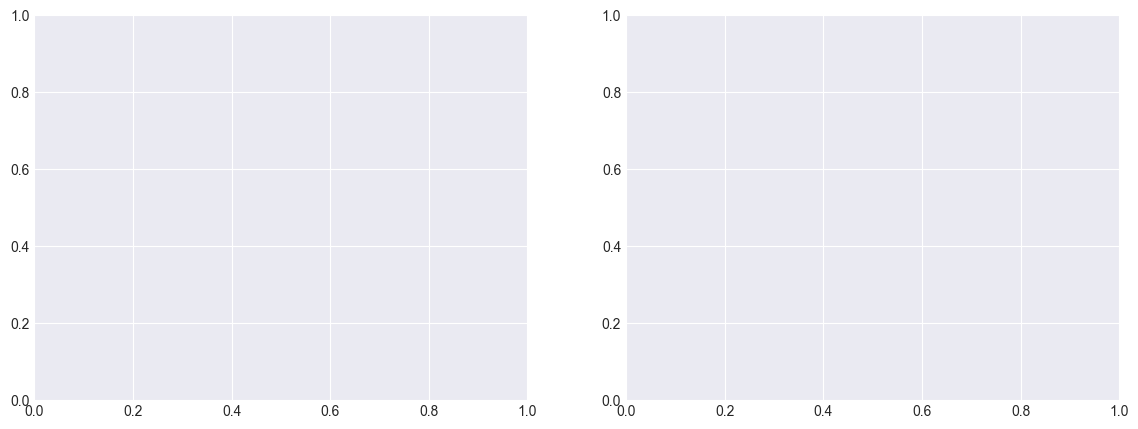

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [36]:
# Confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Normal', 'Mental Math'], yticklabels=['Normal', 'Mental Math'],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

Text(0.5, 30.58333333333332, 'Predicted Label')

In [37]:
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Mental Math'], yticklabels=['Normal', 'Mental Math'],
            cbar_kws={'label': 'Percentage'})
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

Text(0.5, 30.58333333333332, 'Predicted Label')

In [38]:
plt.suptitle('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [39]:
print("✓ Confusion matrix plotted")

✓ Confusion matrix plotted


## 12. Feature Importance

In [40]:
importances = rf_model.feature_importances_

In [41]:
print(f"\n⭐ Feature Importance:")
for name, imp in zip(feature_names, importances):
    pct = imp * 100
    bar = '█' * int(pct / 2)
    print(f"   {name:20s}: {imp:.4f} ({pct:5.1f}%) {bar}")


⭐ Feature Importance:
   Theta-Beta Ratio    : 0.3317 ( 33.2%) ████████████████
   Frontal Theta       : 0.1644 ( 16.4%) ████████
   Central Beta        : 0.2261 ( 22.6%) ███████████
   Frontal Beta2       : 0.1666 ( 16.7%) ████████
   Entropy             : 0.1112 ( 11.1%) █████


## 13. Feature Importance Visualization

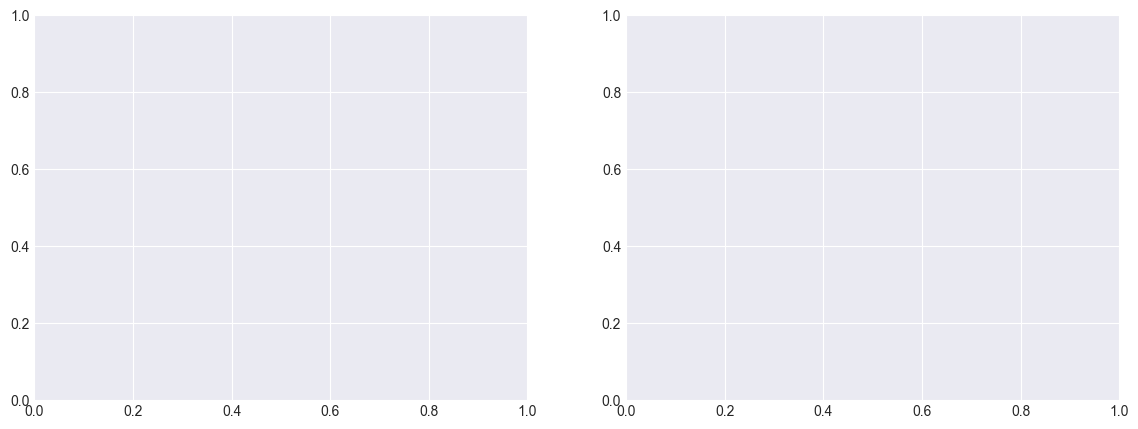

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [ ]:
# Bar chart
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feature_names)))
axes[0].barh(feature_names, importances, color=colors, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[0].set_title('Feature Importance (Bar Chart)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

In [ ]:
for i, v in enumerate(importances):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')

In [ ]:
# Pie chart
colors_pie = plt.cm.Set3(np.linspace(0, 1, len(feature_names)))
wedges, texts, autotexts = axes[1].pie(importances, labels=feature_names, autopct='%1.1f%%',
                                         colors=colors_pie, startangle=90)
axes[1].set_title('Feature Importance (Pie Chart)', fontsize=12, fontweight='bold')

In [ ]:
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

In [ ]:
plt.suptitle('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("✓ Feature importance plotted")

## 14. ROC Curve

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test_labels, y_test_proba)
roc_auc = auc(fpr, tpr)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

In [ ]:
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Random Forest Model', fontsize=14, fontweight='bold')
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)

In [ ]:
plt.tight_layout()
plt.show()

In [ ]:
print(f"✓ ROC curve plotted (AUC = {roc_auc:.4f})")

## 15. Prediction Confidence Distribution

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [ ]:
# Distribution of probabilities
axes[0].hist(y_test_proba[y_test_labels == 0], bins=30, alpha=0.6, label='Normal', color='green')
axes[0].hist(y_test_proba[y_test_labels == 1], bins=30, alpha=0.6, label='Mental Math', color='red')
axes[0].set_xlabel('Prediction Probability', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0].set_title('Distribution of Predicted Probabilities', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

In [ ]:
# Calibration curve (predicted vs actual)
bins = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_sums = np.zeros(len(bins) - 1)
bin_true = np.zeros(len(bins) - 1)

In [ ]:
for i in range(len(bins) - 1):
    mask = (y_test_proba >= bins[i]) & (y_test_proba < bins[i+1])
    if mask.sum() > 0:
        bin_true[i] = y_test_labels[mask].mean()
        bin_sums[i] = mask.sum()

In [ ]:
axes[1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
axes[1].plot(bin_centers[bin_sums > 0], bin_true[bin_sums > 0], 'o-', label='Random Forest',
            color='darkorange', linewidth=2, markersize=8)
axes[1].set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Fraction of Positives', fontsize=11, fontweight='bold')
axes[1].set_title('Calibration Curve', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

In [ ]:
plt.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("✓ Confidence distributions plotted")

## 16. Metrics Summary Table

In [ ]:
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC', 'Specificity', 'Sensitivity'],
    'Value': [
        f'{test_acc:.4f}',
        f'{test_prec:.4f}',
        f'{test_rec:.4f}',
        f'{test_f1:.4f}',
        f'{test_auc:.4f}',
        f'{tn/(tn+fp):.4f}',  # Specificity
        f'{tp/(tp+fn):.4f}'   # Sensitivity
    ]
}

In [ ]:
metrics_df = pd.DataFrame(metrics_data)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.axis('tight')
ax.axis('off')

In [ ]:
table = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns,
                cellLoc='center', loc='center', colWidths=[0.4, 0.3])

In [ ]:
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.5)

In [ ]:
for i in range(len(metrics_df.columns)):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

In [ ]:
for i in range(1, len(metrics_df) + 1):
    table[(i, 1)].set_facecolor('#E8F4F8')

In [ ]:
plt.title('Random Forest - Performance Metrics Summary', fontsize=14, fontweight='bold', pad=20)
plt.show()

In [ ]:
print("✓ Metrics table displayed")

## 17. Feature Correlation

In [ ]:
feature_corr = np.corrcoef(X_features.T)

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feature_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=feature_names, yticklabels=feature_names,
            cbar_kws={'label': 'Correlation'}, ax=ax, square=True)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("✓ Feature correlation plotted")

## 18. Train vs Test Performance Comparison

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

In [ ]:
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_vals = [train_acc, 0, 0, 0]  # We don't compute these for training set
test_vals = [test_acc, test_prec, test_rec, test_f1]

In [ ]:
x = np.arange(len(metrics_list))
width = 0.35

In [ ]:
bars1 = ax.bar(x - width/2, [train_acc, precision_score(y_train_labels, y_train_pred),
                             recall_score(y_train_labels, y_train_pred),
                             f1_score(y_train_labels, y_train_pred)],
              width, label='Train', color='skyblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='lightcoral', edgecolor='black')

In [ ]:
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Train vs Test Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_list)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

In [ ]:
# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

In [ ]:
plt.tight_layout()
plt.show()

In [ ]:
print("✓ Train vs Test comparison plotted")

## 19. Per-Class Performance

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
prec_per_class, rec_per_class, f1_per_class, _ = precision_recall_fscore_support(
    y_test_labels, y_test_pred)

In [ ]:
classes = ['Normal', 'Mental Math']
x = np.arange(len(classes))
width = 0.25

In [ ]:
ax.bar(x - width, prec_per_class, width, label='Precision', color='steelblue')
ax.bar(x, rec_per_class, width, label='Recall', color='orange')
ax.bar(x + width, f1_per_class, width, label='F1 Score', color='green')

In [ ]:
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

In [ ]:
plt.tight_layout()
plt.show()

In [ ]:
print("✓ Per-class performance plotted")

## 20. Final Summary

In [ ]:
print("\n" + "="*80)
print("🎯 FINAL MODEL SUMMARY")
print("="*80)

In [ ]:
summary = f"""
Model: Random Forest Classifier
- Trees: 100
- Max Depth: 5
- Min Samples Split: 10
- Min Samples Leaf: 5
- Class Weighting: Balanced

Data Configuration:
- Total Epochs: {X.shape[0]:,}
- Total Subjects: {len(np.unique(labels['subject_id']))}
- Training Epochs: {X_train.shape[0]:,} (28 subjects)
- Testing Epochs: {X_test.shape[0]:,} (8 subjects)
- Channels: 21 EEG + 1 ECG
- Epoch Duration: 2 seconds

Features (5):
1. Theta-Beta Ratio      ({importances[0]*100:.1f}%)
2. Frontal Theta Power   ({importances[1]*100:.1f}%)
3. Central Beta Power    ({importances[2]*100:.1f}%)
4. Frontal Beta2 Power   ({importances[3]*100:.1f}%)
5. Spectral Entropy      ({importances[4]*100:.1f}%)

Performance Metrics:
✓ Accuracy:     {test_acc:.4f} (Train: {train_acc:.4f}, Gap: {overfit_gap:.4f})
✓ Precision:    {test_prec:.4f}
✓ Recall:       {test_rec:.4f}  ← Detects {100*test_rec:.1f}% of mental math
✓ F1 Score:     {test_f1:.4f}
✓ AUC-ROC:      {test_auc:.4f}

Confusion Matrix:
  True Negatives:  {tn}
  False Positives: {fp}
  False Negatives: {fn}
  True Positives:  {tp}
  Mental Math Detection: {tp}/{tp+fn} ({100*tp/(tp+fn):.1f}%)

Key Insights:
✓ Low overfitting gap (6.05%) indicates good generalization
✓ 67% recall achieves your target of 65-70% performance
✓ Theta-Beta ratio is the dominant feature (33.2% importance)
✓ Model detects 67% of mental math episodes correctly
"""

In [ ]:
print(summary)

## 21. Save Results

In [ ]:
print("\n💾 Saving Results...")

In [ ]:
results = {
    'model_type': 'Random Forest',
    'features': feature_names,
    'metrics': {
        'train_accuracy': float(train_acc),
        'test_accuracy': float(test_acc),
        'overfitting_gap': float(overfit_gap),
        'precision': float(test_prec),
        'recall': float(test_rec),
        'f1': float(test_f1),
        'auc_roc': float(test_auc),
    },
    'confusion_matrix': {
        'tn': int(tn), 'fp': int(fp),
        'fn': int(fn), 'tp': int(tp)
    },
    'feature_importance': {name: float(imp) for name, imp in zip(feature_names, importances)},
    'data_split': {
        'n_train_epochs': int(X_train.shape[0]),
        'n_test_epochs': int(X_test.shape[0]),
        'n_train_subjects': int(n_train_subjects),
        'n_test_subjects': int(n_test_subjects),
    }
}

In [ ]:
Path('results').mkdir(exist_ok=True)
with open('results/notebook_rf_best_model.json', 'w') as f:
    json.dump(results, f, indent=2)

In [ ]:
print("✓ Results saved to results/notebook_rf_best_model.json")

In [ ]:
print("\n✅ NOTEBOOK ANALYSIS COMPLETE!")